# Basic

In [1]:
%load_ext autoreload
%autoreload all

In [2]:
import polars as pl
import pickle
import numpy as np
import tqdm
import os
import json
import glob
import multiprocessing as mp

import src.graph_tokenizer_gd_tree_dev.config as config
import src.graph_tokenizer_gd_tree_dev.tokenizer as tokenizer


# 1. get patient traj

In [9]:
df_traj = pl.scan_parquet(config.TimelineData().all_patient_traj)
with open(config.TimelineData().used_cpt) as f:
    data = json.load(f)

rows = []
for category, terms in data.items():
    if isinstance(terms, dict):
        for term, label in terms.items():
            rows.append({"category": category, "term": term, "label": label})
    elif isinstance(terms, list):
        for term in terms:
            rows.append({"category": category, "term": term, "label": None})
    else:
        rows.append({"category": category, "term": None, "label": terms})

df = pl.DataFrame(rows)

# 2. get patient first date of IA and rupture

In [27]:
df_patient_first_ia = (df_traj
              .filter(pl.col("mapped_code").is_in(config.TimelineVocab().ANEURYSM_CODES))
              .group_by("unique_patient_id")
              .agg(pl.col("date").sort().first())
              .rename({"date": "first_date_ia"})
              .collect())


In [28]:
sah_vocab = df.filter(pl.col("category").str.contains("SAH"))["term"].unique()
df_patient_first_rupture = (df_traj
               .filter(pl.col("mapped_label").is_in(sah_vocab))
               .group_by("unique_patient_id")
               .agg(pl.col("date").sort().first())
               .rename({"date": "first_date_rupture"})
               .collect())


# get usable patient id according to event order

In [25]:
patient_w_sah = set(df_patient_first_rupture["unique_patient_id"].to_list())
patient_w_ia = set(df_patient_first_ia["unique_patient_id"].to_list())
patient_included = list(patient_w_sah.intersection(patient_w_ia).union(patient_w_ia))

In [ ]:
patient_to_keep_w_sah = set(df_patient_first_ia
 .join(df_patient_first_rupture, on = "unique_patient_id", how = "left")
 .drop_nulls()
 .with_columns(gap_ia_rupture = pl.col("first_date_rupture") - pl.col("first_date_ia"))
 .with_columns(
    pl.when(pl.col("gap_ia_rupture") > 0).then(pl.lit("incident (usable)"))
      .when(pl.col("gap_ia_rupture") == 0).then(pl.lit("same-day (contaminated)"))
      .otherwise(pl.lit("rupture-first (anomaly)"))
      .alias("bucket"))
 .filter((pl.col("bucket") == "same-day (contaminated)") | (pl.col("bucket") == "incident (usable)"))
 ["unique_patient_id"]
 )

patient_anomaly = set(
    df_patient_first_ia
    .join(df_patient_first_rupture, on="unique_patient_id", how="left")
    .drop_nulls()
    .filter((pl.col("first_date_rupture") - pl.col("first_date_ia")) < 0)
    ["unique_patient_id"]
)
patient_to_keep = patient_w_ia - patient_anomaly


1880

# define usable time window L, crop trajectory of patients from the start till (onset IA - L)

In [ ]:
L = 30 # days
min_code = 10

patient_to_keep_cropped_ids = (df_traj
 .select("date", "unique_patient_id", "mapped_code", "mapping_type")
 .filter(pl.col("unique_patient_id").is_in(list(patient_to_keep))) # get kept patients' whole traj
 .join(df_patient_first_ia.lazy(), on = "unique_patient_id") # join to get their first onset (SNOMED, CIM, CHOP)
 .with_columns(day_gap_first_ia = (pl.col("first_date_ia") - pl.col("date")).dt.total_days()) # compute day gap event to IA onset
 .filter(pl.col("day_gap_first_ia") >= L) # crop traj
 .filter(pl.col("mapping_type") == "SNOMED") # keep only snomed for the tokenizer
 .drop("mapping_type")
 .unique()
 .group_by("unique_patient_id") # get number of distinct SNOMED codes per patient in the cropped traj
 .agg(num_code = pl.col("mapped_code").n_unique())
 .filter(pl.col("num_code")>=min_code)
 .collect()
 ["unique_patient_id"])

traj_cropped = (df_traj
 .select("date", "unique_patient_id", "mapped_code", "mapping_type")
 .filter(pl.col("unique_patient_id").is_in(patient_to_keep_cropped_ids)) # get kept patients' whole traj
 .join(df_patient_first_ia.lazy(), on = "unique_patient_id") # join to get their first onset (SNOMED, CIM, CHOP)
 .with_columns(day_gap_first_ia = (pl.col("first_date_ia") - pl.col("date")).dt.total_days()) # compute day gap event to IA onset
 .filter(pl.col("day_gap_first_ia") >= L) # crop traj
 .filter(pl.col("mapping_type") == "SNOMED") # keep only snomed for the tokenizer
 .drop("mapping_type")
 .unique()
 .collect())

traj_cropped

date,unique_patient_id,mapped_code,first_date_ia,day_gap_first_ia
datetime[μs],str,str,datetime[μs],i64
1993-03-09 10:43:59.999981,"""332881bb6aa65713151a4a597efcc8…","""418433008""",2012-07-09 15:28:59.999991,7062
2001-10-16 12:07:46.999981,"""47a3cc7855f3b2bfc96469b1f7cc5f…","""702852001""",2018-05-12 10:12:59.999991,6051
2015-07-29 10:55:14.999991,"""d5743902ed65cd126e96807b2df431…","""312251004+312275004""",2015-09-01 07:24:59.999991,33
2011-10-10 07:53:59.999991,"""f2846de94c080ec74827932b0c0ee0…","""312421008""",2021-04-15 08:11:59.999991,3475
2017-10-14 05:59:59.999991,"""844088df3d88e88fa04b538e174e46…","""116602009""",2020-02-11 10:16:59.999991,850
…,…,…,…,…
2023-11-27 10:02:05.999991,"""21aa3ae6da4eec1ae897427dade420…","""225433007""",2024-03-21 08:22:59.999991,114
2023-07-06 05:59:59.999991,"""e613ef2fb69b15ca10147d4742e821…","""346628003""",2023-08-25 13:26:59.999991,50
2012-11-16 06:59:59.999991,"""5da3dcd54d2b4f2959e231b0f49354…","""786134002""",2022-06-03 10:58:59.999991,3486


In [ ]:
len(set(traj_cropped["unique_patient_id"].unique()).intersection(patient_w_sah)), len(set(traj_cropped["unique_patient_id"].unique()).intersection(patient_w_ia)),

(299, 1399)

In [ ]:
df_gender = pl.read_parquet(config.TimelineData().patient_gender)
df_gender

date,unique_patient_id,source_collection,mapped_code,mapped_label,mapping_type,value,value_binned,unit_code,unit_code_label,true_stay_id,birthday,age_gap_day
datetime[μs],str,str,str,str,str,f64,str,str,str,str,datetime[μs],f64


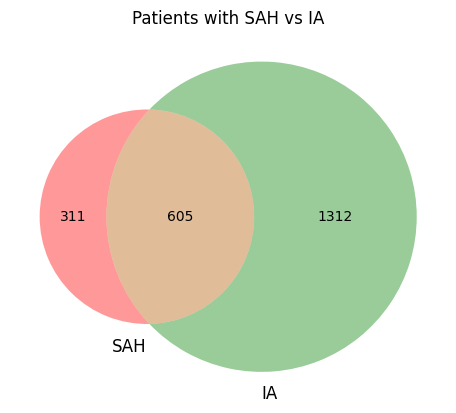

In [20]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

venn2([patient_w_sah, patient_w_ia], set_labels=("SAH", "IA"))
plt.title("Patients with SAH vs IA")
plt.show()